# Stroke Risk Prediction — Exploratory Data Analysis (V1)

**Dataset** : Ping Wang (2024), *Imbalanced Data-based Prediction and Risk Factor Analysis of Stroke*, Mendeley Data. DOI: [10.17632/xggs239bnw.1](https://doi.org/10.17632/xggs239bnw.1)  
**Source** : NHANES (National Health and Nutrition Examination Survey)  
**Objectif** : Analyse exploratoire de base pour comprendre la structure des données et identifier les premières observations.  

---
> **Version V1** : Analyse basique (distributions, déséquilibre classes, corrélations simples).  

## 1. Imports & Configuration

In [1]:
import sys
sys.path.insert(0, './src')

import importlib, config
importlib.reload(config)

from config import check_data_quality, save_features, LABEL_MAPS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('../dataset/data.csv')

print(f'Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

Shape : 4603 rows × 36 columns
Memory usage : 1294.7 KB


,stroke,gender,age,Race,Marital status,alcohol,smoke,sleep disorder,Health Insurance,General health condition,...,energy,protein,Carbohydrate,Dietary fiber,Total fat,Total saturated fatty acids,Total monounsaturated fatty acids,Total polyunsaturated fatty acids,Potassium,Sodium
0,0,2,2,5,1,0,0,2,2,3,...,1598,62.78,192.19,10.0,65.64,25.112,24.090,8.543,2887,2969
1,0,2,2,1,1,0,0,1,2,3,...,1547,45.35,256.02,17.0,42.56,13.423,15.389,10.613,2058,2091
2,1,1,2,3,1,1,1,2,1,3,...,2466,81.56,254.49,13.0,103.32,43.295,36.727,15.366,3117,5233
3,0,2,3,3,1,1,1,2,1,4,...,1605,70.99,143.37,10.0,81.60,24.527,30.567,18.174,1766,3706
4,0,1,1,4,1,0,0,2,1,2,...,1818,74.75,229.45,14.2,67.49,26.030,24.837,10.533,1842,2461


In [3]:
# Nettoyage des noms de colonnes — 'alcohol ' contient un espace
df.columns = df.columns.str.strip()

## 3. Basic Dataset Information

In [4]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4603 entries, 0 to 4602
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   stroke                             4603 non-null   int64  
 1   gender                             4603 non-null   int64  
 2   age                                4603 non-null   int64  
 3   Race                               4603 non-null   int64  
 4   Marital status                     4603 non-null   int64  
 5   alcohol                            4603 non-null   int64  
 6   smoke                              4603 non-null   int64  
 7   sleep disorder                     4603 non-null   int64  
 8   Health Insurance                   4603 non-null   int64  
 9   General health condition           4603 non-null   int64  
 10  depression                         4603 non-null   int64  
 11  sleep time                         4603 non-null   float

In [5]:
# Descriptive statistics
df.describe().round(2)

,stroke,gender,age,Race,Marital status,alcohol,smoke,sleep disorder,Health Insurance,General health condition,...,energy,protein,Carbohydrate,Dietary fiber,Total fat,Total saturated fatty acids,Total monounsaturated fatty acids,Total polyunsaturated fatty acids,Potassium,Sodium
count,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,...,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00,4603.00
mean,0.08,1.55,2.24,3.07,2.28,0.73,0.52,1.75,1.13,3.21,...,2010.28,77.49,240.30,16.07,77.77,25.08,27.89,17.83,2572.36,3349.22
std,0.27,0.50,0.66,1.04,1.63,0.45,0.50,0.43,0.34,0.93,...,935.66,40.01,118.86,9.95,44.60,15.79,16.94,11.97,1226.70,1743.58
min,0.00,1.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.00
25%,0.00,1.00,2.00,3.00,1.00,0.00,0.00,2.00,1.00,3.00,...,1365.00,50.24,160.38,9.30,46.28,14.15,16.14,9.56,1732.00,2154.50
50%,0.00,2.00,2.00,3.00,1.00,1.00,1.00,2.00,1.00,3.00,...,1856.00,70.26,221.17,14.00,69.51,21.92,24.34,15.06,2386.00,3027.00
75%,0.00,2.00,3.00,4.00,3.00,1.00,1.00,2.00,1.00,4.00,...,2467.00,95.46,296.29,20.50,99.32,32.33,35.82,23.27,3218.50,4178.00
max,1.00,2.00,3.00,5.00,6.00,1.00,1.00,2.00,2.00,5.00,...,13687.00,387.37,1815.02,107.00,553.79,205.67,221.67,147.08,14812.00,20183.00


In [6]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

# Duplicate rows
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
No missing values found.

Duplicate rows: 0


In [7]:
# Variable classification
CATEGORICAL_VARS = [
    'gender', 'age', 'Race', 'Marital status',
    'alcohol', 'smoke', 'sleep disorder', 'Health Insurance',
    'General health condition', 'depression',
    'diabetes', 'hypertension', 'high cholesterol',
    'Coronary Heart Disease', 'Body Mass Index'
]

NUMERICAL_VARS = [
    'sleep time', 'Minutes sedentary activity', 'Waist Circumference',
    'Systolic blood pressure', 'Diastolic blood pressure',
    'High-density lipoprotein', 'Triglyceride', 'Low-density lipoprotein',
    'Fasting Glucose', 'Glycohemoglobin',
    'energy', 'protein', 'Carbohydrate', 'Dietary fiber', 'Total fat',
    'Total saturated fatty acids', 'Total monounsaturated fatty acids',
    'Total polyunsaturated fatty acids', 'Potassium', 'Sodium'
]

print(f'Categorical variables : {len(CATEGORICAL_VARS)}')
print(f'Numerical variables   : {len(NUMERICAL_VARS)}')

Categorical variables : 15
Numerical variables   : 20


## 4. Target Variable — Class Imbalance

La première observation critique : la distribution de la variable cible `stroke`.

In [8]:
# Class counts
stroke_counts = df['stroke'].value_counts()
stroke_pct    = df['stroke'].value_counts(normalize=True) * 100

print('=== Target Variable Distribution ===')
print(f'  No stroke (0) : {stroke_counts[0]:>5}  ({stroke_pct[0]:.2f}%)')
print(f'  Stroke    (1) : {stroke_counts[1]:>5}  ({stroke_pct[1]:.2f}%)')
print(f'  Imbalance ratio : {stroke_counts[0]/stroke_counts[1]:.1f}:1')

=== Target Variable Distribution ===
  No stroke (0) :  4241  (92.14%)
  Stroke    (1) :   362  (7.86%)
  Imbalance ratio : 11.7:1


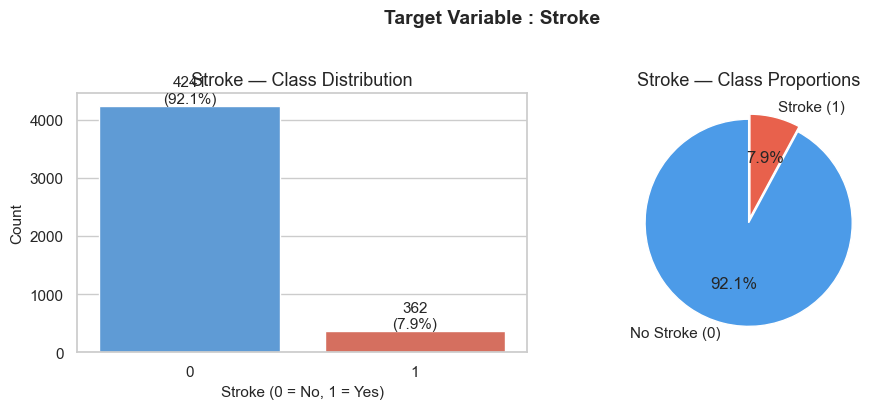

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Countplot
sns.countplot(
    x='stroke', data=df,
    palette=['#4C9BE8', '#E8614C'],
    ax=axes[0]
)
axes[0].set_title('Stroke — Class Distribution')
axes[0].set_xlabel('Stroke (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

# Pie chart
axes[1].pie(
    stroke_counts,
    labels=['No Stroke (0)', 'Stroke (1)'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#E8614C'],
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Stroke — Class Proportions')

plt.suptitle('Target Variable : Stroke', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Numerical Variables

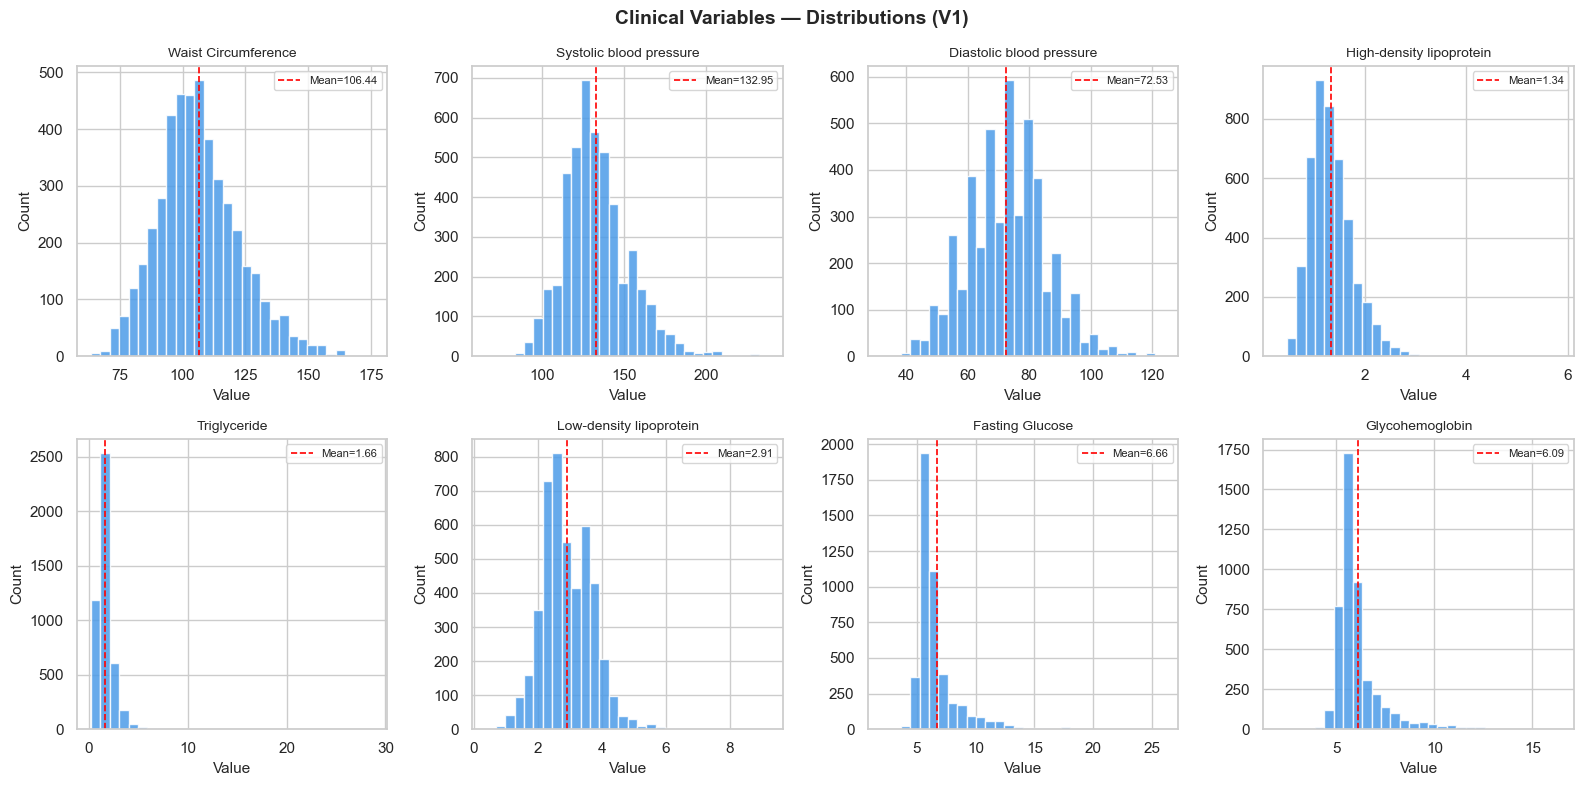

In [10]:
# Group 1 : Clinical measurements
clinical_vars = [
    'Waist Circumference', 'Systolic blood pressure',
    'Diastolic blood pressure', 'High-density lipoprotein',
    'Triglyceride', 'Low-density lipoprotein',
    'Fasting Glucose', 'Glycohemoglobin'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(clinical_vars):
    axes[i].hist(df[var], bins=30, color='#4C9BE8', edgecolor='white', alpha=0.85)
    axes[i].set_title(var, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={df[var].mean():.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Clinical Variables — Distributions (V1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

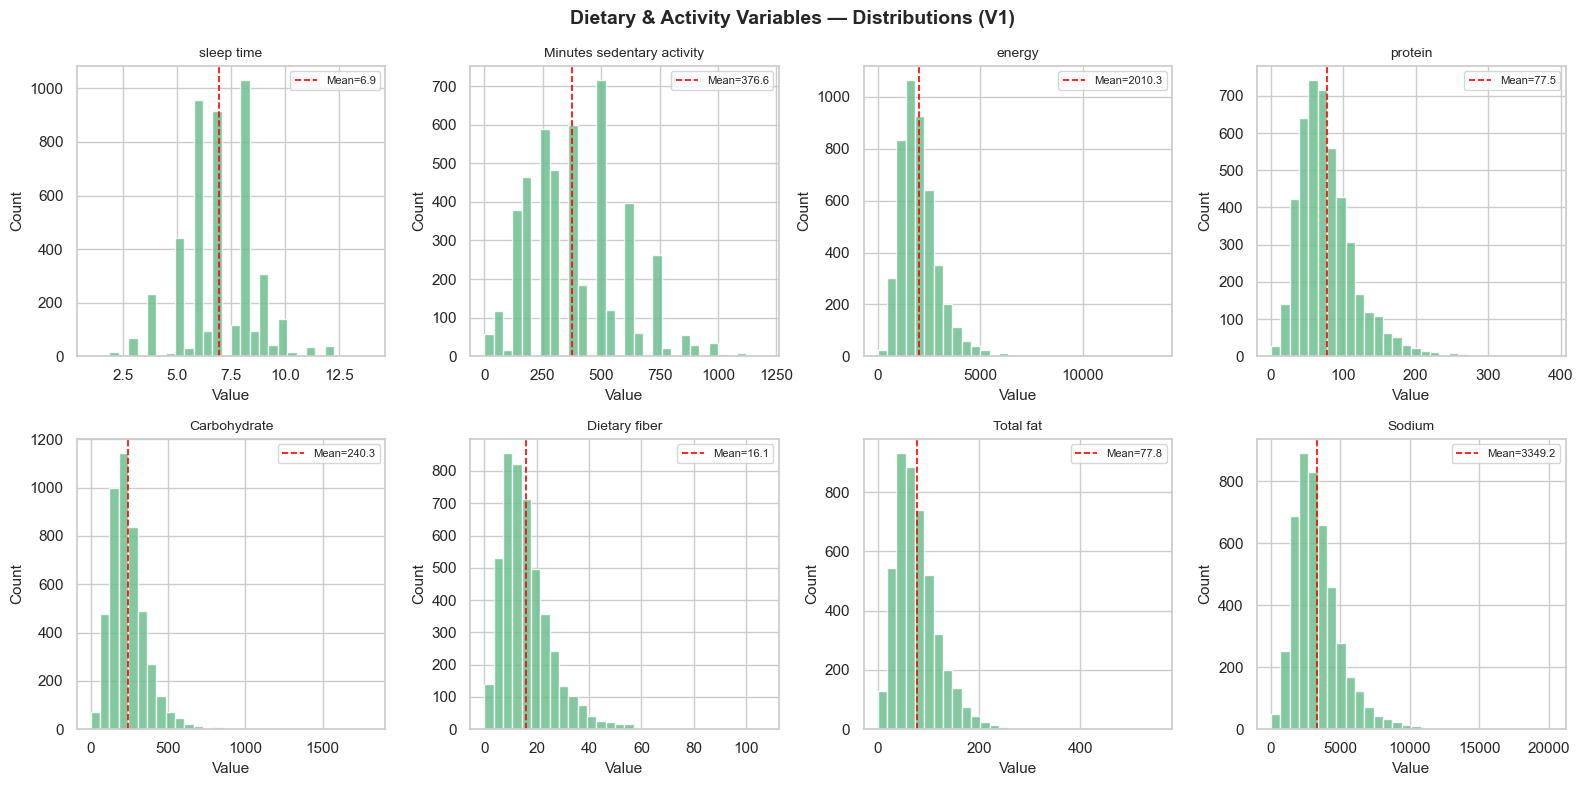

In [11]:
# Group 2 : Dietary & activity variables
diet_vars = [
    'sleep time', 'Minutes sedentary activity',
    'energy', 'protein', 'Carbohydrate', 'Dietary fiber',
    'Total fat', 'Sodium'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(diet_vars):
    axes[i].hist(df[var], bins=30, color='#6DBF8E', edgecolor='white', alpha=0.85)
    axes[i].set_title(var, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={df[var].mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Dietary & Activity Variables — Distributions (V1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Categorical Variables — Frequency Distributions

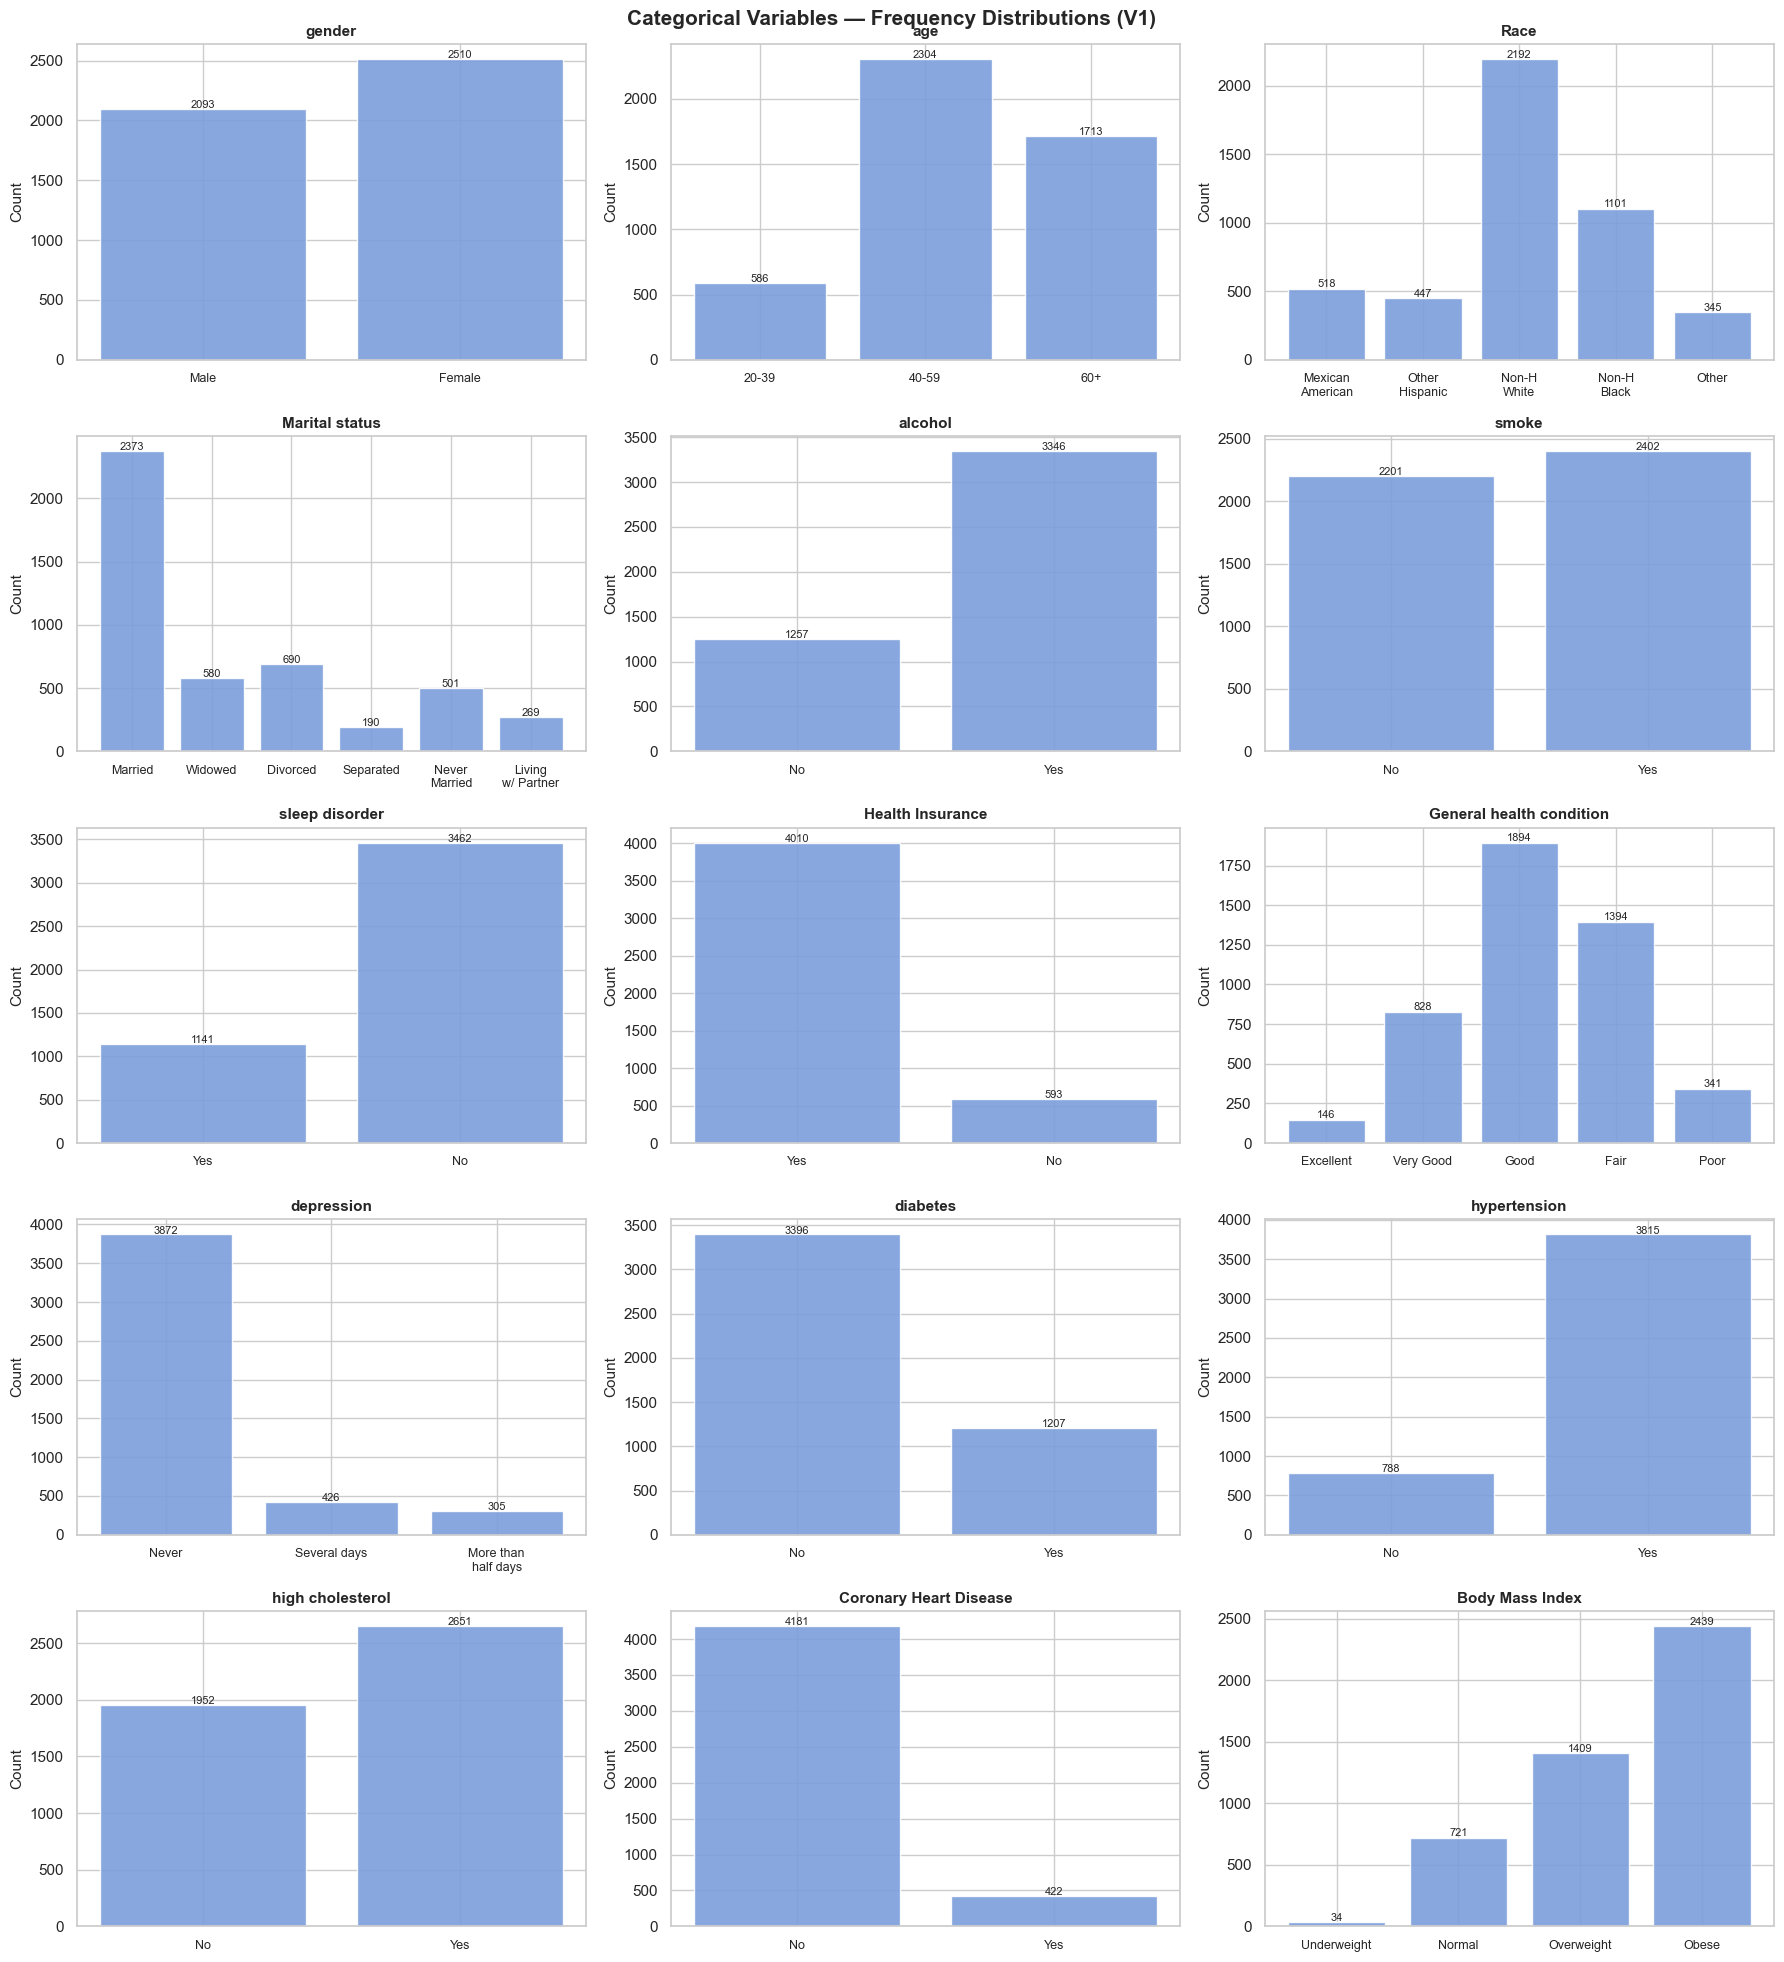

In [12]:
# Mapping dictionaries for readability
label_maps = {
    'gender'                   : {1: 'Male', 2: 'Female'},
    'age'                      : {1: '20-39', 2: '40-59', 3: '60+'},
    'Race'                     : {1: 'Mexican\nAmerican', 2: 'Other\nHispanic', 3: 'Non-H\nWhite', 4: 'Non-H\nBlack', 5: 'Other'},
    'Marital status'           : {1: 'Married', 2: 'Widowed', 3: 'Divorced', 4: 'Separated', 5: 'Never\nMarried', 6: 'Living\nw/ Partner'},
    'alcohol'                 : {0: 'No', 1: 'Yes'},
    'smoke'                    : {0: 'No', 1: 'Yes'},
    'sleep disorder'           : {1: 'Yes', 2: 'No'},
    'Health Insurance'         : {1: 'Yes', 2: 'No'},
    'General health condition' : {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'},
    'depression'               : {1: 'Never', 2: 'Several days', 3: 'More than\nhalf days'},
    'diabetes'                 : {0: 'No', 1: 'Yes'},
    'hypertension'             : {0: 'No', 1: 'Yes'},
    'high cholesterol'         : {0: 'No', 1: 'Yes'},
    'Coronary Heart Disease'   : {0: 'No', 1: 'Yes'},
    'Body Mass Index'          : {1: 'Underweight', 2: 'Normal', 3: 'Overweight', 4: 'Obese'},
}

cat_vars_to_plot = CATEGORICAL_VARS

n_cols = 3
n_rows = (len(cat_vars_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, var in enumerate(cat_vars_to_plot):
    counts = df[var].value_counts().sort_index()
    labels = [label_maps.get(var, {}).get(k, str(k)) for k in counts.index]

    axes[i].bar(labels, counts.values, color='#7B9EDB', edgecolor='white', alpha=0.9)
    axes[i].set_title(var, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', labelsize=9)

    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Variables — Frequency Distributions (V1)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Basic Correlation Analysis

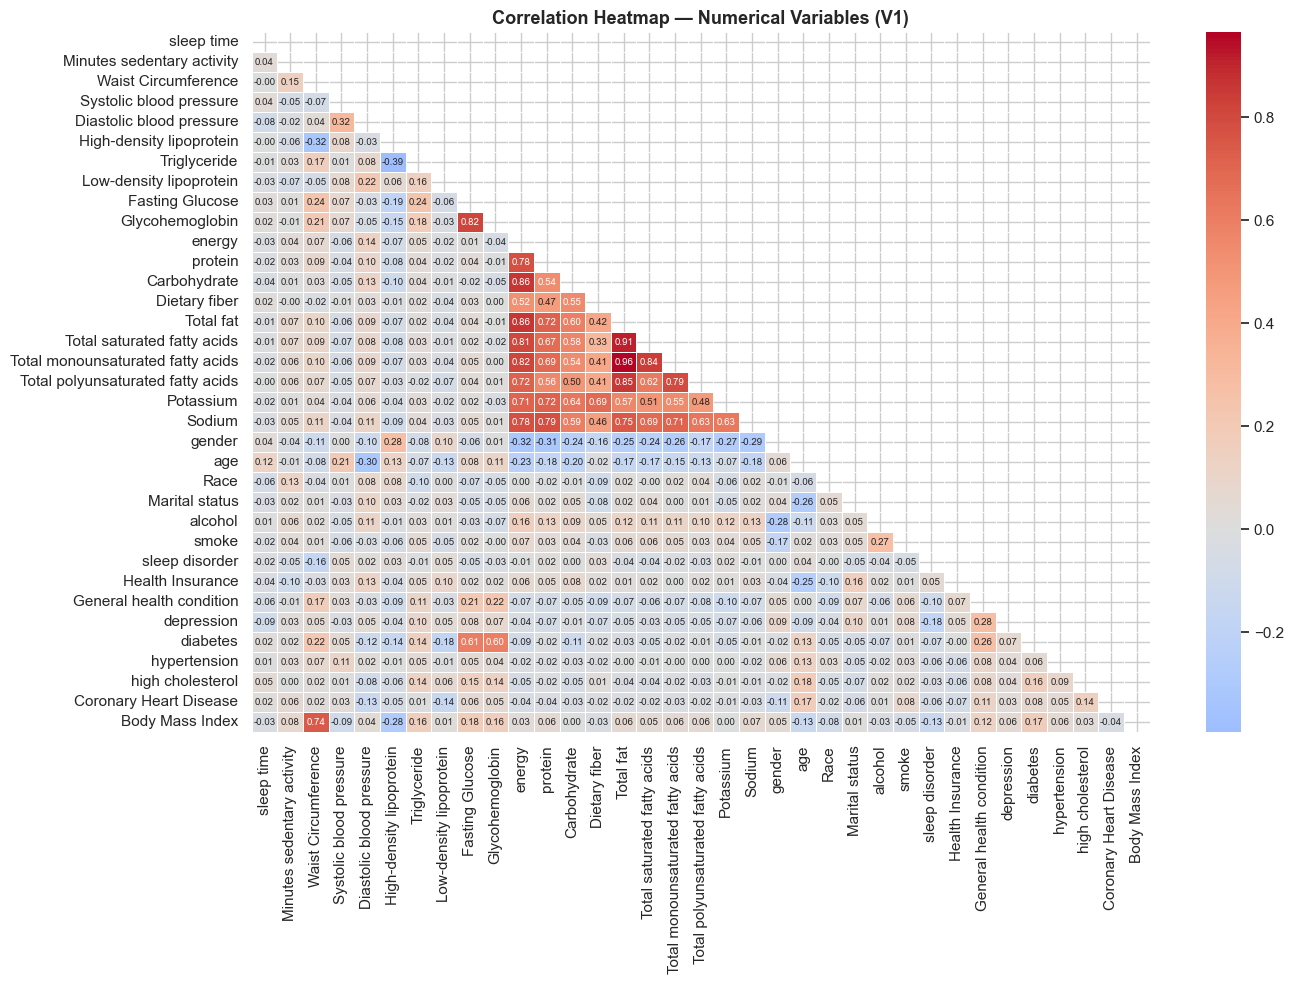

In [13]:
# Correlation matrix on numerical variables only
all_vars = NUMERICAL_VARS + CATEGORICAL_VARS 
corr_matrix = df[all_vars].corr()

fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Correlation Heatmap — Numerical Variables (V1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

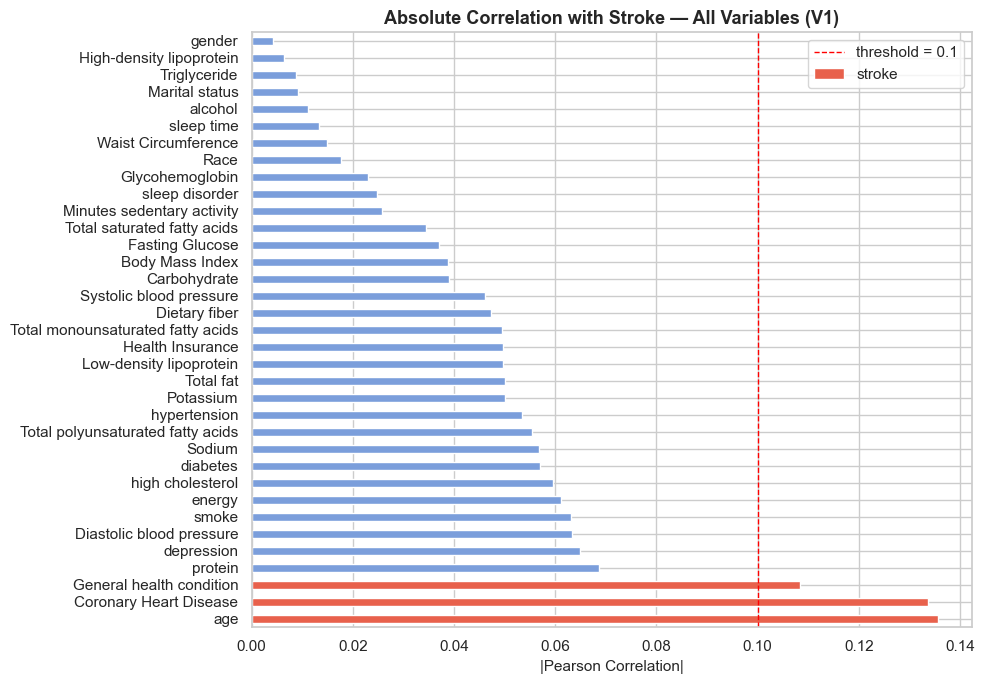

Top 10 variables correlated with stroke:
age                         0.136
Coronary Heart Disease      0.134
General health condition    0.108
protein                     0.069
depression                  0.065
Diastolic blood pressure    0.063
smoke                       0.063
energy                      0.061
high cholesterol            0.060
diabetes                    0.057
Name: stroke, dtype: float64


In [14]:
# Top correlations with stroke (including categorical)
corr_with_stroke = df.corr(numeric_only=True)['stroke'].drop('stroke').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
corr_with_stroke.plot(
    kind='barh',
    ax=ax,
    color=[
        '#E8614C' if v >= 0.1 else '#7B9EDB'
        for v in corr_with_stroke.values
    ],
    edgecolor='white'
)
ax.set_title('Absolute Correlation with Stroke — All Variables (V1)', fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson Correlation|')
ax.axvline(0.1, color='red', linestyle='--', linewidth=1, label='threshold = 0.1')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 variables correlated with stroke:')
print(corr_with_stroke.head(10).round(3))

In [15]:
# Sauvegarde dans src/features.json — utilisé par Preprocessing et Modeling
save_features(CATEGORICAL_VARS, NUMERICAL_VARS)

features.json sauvegarde dans ./src/features.json
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables
  all_features     : 35 variables


## 8. Key Observations & Conclusions (V1)

### Ce qu'on a trouvé

| Observation | Détail |
|---|---|
| **Déséquilibre classes sévère** | 92.14% non-stroke vs 7.86% stroke (ratio ~11:1) |
| **Aucune valeur manquante** | 0 valeurs manquantes sur 36 variables |
| **Aucun doublon** | Dataset propre |
| **Variables ordinales encodées** | age, BMI, General health → valeurs entières ordonnées |
| **Distributions asymétriques** | Triglyceride, Fasting Glucose, energy → queues longues à droite |
| **Variables les plus corrélées** | age, Glycohemoglobin, hypertension, Fasting Glucose |